## Phase 4 - Feature Engineering and ML Modeling

Two models we are building:
1. LightGBM - predicts monthly spending per category (forecasting)
2. Isolation Forest - detects anomalous/fraudulent transactions

Both models feed directly into the LLM insight layer in Phase 5.

Key findings from EDA that drive our modeling decisions:
- Fraud transactions are 7.9x larger on average - use log transformed amount
- Online transactions have 3x higher fraud rate - create is_online feature
- Day of week affects spending amount - create day_of_week feature
- Monthly data has gaps - use Prophet not moving average

In [1]:
# Cell 1 - Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             precision_score,
                             recall_score)
import lightgbm as lgb

# Load currency converted dataset
bw = pd.read_csv('../Data/processed/budgetwise_usd_converted.csv',
                 parse_dates=['date'])
fraud = pd.read_csv('../Data/processed/fraud_train_cleaned.csv',
                    parse_dates=['date'])

print("Datasets loaded")
print(f"BudgetWise: {bw.shape[0]:,} rows")
print(f"Fraud: {fraud.shape[0]:,} rows")   

Datasets loaded
BudgetWise: 14,540 rows
Fraud: 1,296,675 rows


### Part 1 - Feature Engineering
Converting raw columns into meaningful signals for the ML models.
Each feature is derived directly from EDA insights.

In [2]:
# Cell 2 - Feature Engineering for BudgetWise
print("Engineering features for BudgetWise dataset...")

# Separate expenses only - we forecast spending not income
bw_exp = bw[bw['transaction_type'] == 'Expense'].copy()

# Time-based features
bw_exp['year'] = bw_exp['date'].dt.year
bw_exp['month'] = bw_exp['date'].dt.month
bw_exp['day'] = bw_exp['date'].dt.day
bw_exp['day_of_week'] = bw_exp['date'].dt.dayofweek  # 0=Monday, 6=Sunday
bw_exp['is_weekend'] = (bw_exp['day_of_week'] >= 5).astype(int)
bw_exp['quarter'] = bw_exp['date'].dt.quarter

# High spend day feature - from EDA insight 4
# Tuesday=1, Sunday=6 are high spend days
bw_exp['is_high_spend_day'] = bw_exp['day_of_week'].isin([1, 6]).astype(int)

# Amount features - log transform to handle skewness
# from EDA insight 6
bw_exp['log_amount'] = np.log1p(bw_exp['amount'])

# Rolling average - last 7 days spending per user
bw_exp = bw_exp.sort_values(['user_id', 'date'])
bw_exp['rolling_avg_7d'] = (bw_exp.groupby('user_id')['amount']
                             .transform(lambda x: x.rolling(7, min_periods=1)
                             .mean()))

# Encode categorical columns
le_category = LabelEncoder()
le_payment = LabelEncoder()
le_location = LabelEncoder()

bw_exp['category_encoded'] = le_category.fit_transform(bw_exp['category'])
bw_exp['payment_encoded'] = le_payment.fit_transform(bw_exp['payment_mode'])
bw_exp['location_encoded'] = le_location.fit_transform(bw_exp['location'])

print("Features engineered successfully")
print(f"Shape: {bw_exp.shape[0]:,} rows x {bw_exp.shape[1]} columns")
print()
print("New features created:")
new_features = ['year', 'month', 'day', 'day_of_week', 'is_weekend',
                'quarter', 'is_high_spend_day', 'log_amount',
                'rolling_avg_7d', 'category_encoded',
                'payment_encoded', 'location_encoded']
for f in new_features:
    print(f"  {f}: {bw_exp[f].dtype} | sample: {bw_exp[f].head(3).tolist()}")

Engineering features for BudgetWise dataset...
Features engineered successfully
Shape: 12,346 rows x 23 columns

New features created:
  year: int32 | sample: [2019, 2019, 2019]
  month: int32 | sample: [1, 3, 3]
  day: int32 | sample: [11, 5, 17]
  day_of_week: int32 | sample: [4, 1, 6]
  is_weekend: int64 | sample: [0, 0, 1]
  quarter: int32 | sample: [1, 1, 1]
  is_high_spend_day: int64 | sample: [0, 1, 1]
  log_amount: float64 | sample: [4.709530201312334, 5.5254529391317835, 5.8916442118257715]
  rolling_avg_7d: float64 | sample: [110.0, 180.0, 240.33333333333334]
  category_encoded: int64 | sample: [2, 6, 5]
  payment_encoded: int64 | sample: [33, 37, 51]
  location_encoded: int64 | sample: [9, 1, 1]


In [3]:
# Cell 3 - Feature Engineering for Fraud Dataset
print("Engineering features for Fraud dataset...")

fraud_feat = fraud.copy()

# Time features
fraud_feat['hour'] = fraud_feat['date'].dt.hour
fraud_feat['day_of_week'] = fraud_feat['date'].dt.dayofweek
fraud_feat['month'] = fraud_feat['date'].dt.month
fraud_feat['is_night'] = ((fraud_feat['hour'] >= 22) | 
                          (fraud_feat['hour'] <= 6)).astype(int)

# Online transaction feature - from EDA insight 5
fraud_feat['is_online'] = fraud_feat['category'].str.endswith('_net').astype(int)

# Amount features - log transform
fraud_feat['log_amount'] = np.log1p(fraud_feat['amount'])

# Geographic distance between cardholder and merchant
# Large distance = suspicious
fraud_feat['geo_distance'] = np.sqrt(
    (fraud_feat['lat'] - fraud_feat['merchant_lat'])**2 +
    (fraud_feat['long'] - fraud_feat['merchant_long'])**2
)

# Age from date of birth
fraud_feat['dob'] = pd.to_datetime(fraud_feat['dob'])
fraud_feat['age'] = ((fraud_feat['date'] - fraud_feat['dob'])
                     .dt.days / 365.25).astype(int)

# Encode category
le_fraud_cat = LabelEncoder()
fraud_feat['category_encoded'] = le_fraud_cat.fit_transform(
    fraud_feat['category'])

print("Fraud features engineered successfully")
print(f"Shape: {fraud_feat.shape[0]:,} rows x {fraud_feat.shape[1]} columns")
print()
print("New features created:")
new_fraud_features = ['hour', 'day_of_week', 'month', 'is_night',
                      'is_online', 'log_amount', 'geo_distance', 'age']
for f in new_fraud_features:
    print(f"  {f}: min={fraud_feat[f].min():.2f} "
          f"max={fraud_feat[f].max():.2f} "
          f"mean={fraud_feat[f].mean():.2f}")

Engineering features for Fraud dataset...
Fraud features engineered successfully
Shape: 1,296,675 rows x 25 columns

New features created:
  hour: min=0.00 max=23.00 mean=12.80
  day_of_week: min=0.00 max=6.00 mean=3.07
  month: min=1.00 max=12.00 mean=6.14
  is_night: min=0.00 max=1.00 mean=0.33
  is_online: min=0.00 max=1.00 mean=0.16
  log_amount: min=0.69 max=10.27 mean=3.53
  geo_distance: min=0.00 max=1.41 mean=0.77
  age: min=13.00 max=95.00 mean=45.50


In [4]:
# Cell 4 - Isolation Forest Anomaly Detection Model
print("Building Isolation Forest model...")
print()

# Select features for anomaly detection
feature_cols = ['log_amount', 'is_online', 'is_night', 
                'geo_distance', 'hour', 'day_of_week',
                'month', 'age', 'category_encoded', 'city_pop']

X = fraud_feat[feature_cols].fillna(0)
y = fraud_feat['is_fraud']

print(f"Training on {X.shape[0]:,} transactions")
print(f"Features used: {feature_cols}")
print()

# Train Isolation Forest
# contamination = expected fraud rate from EDA (0.58%)
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.0058,
    random_state=42,
    n_jobs=-1
)

print("Training Isolation Forest...")
iso_forest.fit(X)

# Predict - Isolation Forest returns -1 for anomaly, 1 for normal
predictions = iso_forest.predict(X)
# Convert to 0/1 format - 1 means fraud
fraud_feat['anomaly_predicted'] = (predictions == -1).astype(int)

# Evaluate
print("Model Evaluation:")
print()
print(classification_report(y, fraud_feat['anomaly_predicted'],
                            target_names=['Normal', 'Fraud']))
print()

# Key metrics
precision = precision_score(y, fraud_feat['anomaly_predicted'])
recall = recall_score(y, fraud_feat['anomaly_predicted'])
print(f"Precision: {precision:.3f} - of transactions flagged as fraud, {precision*100:.1f}% were actually fraud")
print(f"Recall: {recall:.3f} - of actual fraud cases, {recall*100:.1f}% were caught")

Building Isolation Forest model...

Training on 1,296,675 transactions
Features used: ['log_amount', 'is_online', 'is_night', 'geo_distance', 'hour', 'day_of_week', 'month', 'age', 'category_encoded', 'city_pop']

Training Isolation Forest...
Model Evaluation:

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1289169
       Fraud       0.16      0.16      0.16      7506

    accuracy                           0.99   1296675
   macro avg       0.58      0.58      0.58   1296675
weighted avg       0.99      0.99      0.99   1296675


Precision: 0.161 - of transactions flagged as fraud, 16.1% were actually fraud
Recall: 0.161 - of actual fraud cases, 16.1% were caught


In [5]:
# Cell 5 - LightGBM Supervised Fraud Classifier
print("Building LightGBM supervised model...")
print()

# Same features as Isolation Forest
feature_cols = ['log_amount', 'is_online', 'is_night',
                'geo_distance', 'hour', 'day_of_week',
                'month', 'age', 'category_encoded', 'city_pop']

X = fraud_feat[feature_cols].fillna(0)
y = fraud_feat['is_fraud']

# Train/test split - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]:,} transactions")
print(f"Test set: {X_test.shape[0]:,} transactions")
print()

# Handle class imbalance - tell LightGBM fraud is rare
# scale_pos_weight = normal count / fraud count
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio: {scale:.0f}:1 (normal:fraud)")
print()

# Train LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("Training LightGBM...")
lgb_model.fit(X_train, y_train)

# Evaluate on test set
y_pred = lgb_model.predict(X_test)
y_prob = lgb_model.predict_proba(X_test)[:, 1]

print("LightGBM Model Evaluation:")
print()
print(classification_report(y_test, y_pred,
                            target_names=['Normal', 'Fraud']))
print()

roc_auc = roc_auc_score(y_test, y_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Precision: {precision:.3f} - of transactions flagged, {precision*100:.1f}% were actually fraud")
print(f"Recall: {recall:.3f} - of actual fraud cases, {recall*100:.1f}% were caught")

Building LightGBM supervised model...

Training set: 1,037,340 transactions
Test set: 259,335 transactions

Class imbalance ratio: 172:1 (normal:fraud)

Training LightGBM...
LightGBM Model Evaluation:

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99    257834
       Fraud       0.25      0.98      0.40      1501

    accuracy                           0.98    259335
   macro avg       0.62      0.98      0.69    259335
weighted avg       1.00      0.98      0.99    259335


ROC-AUC Score: 0.9978
Precision: 0.249 - of transactions flagged, 24.9% were actually fraud
Recall: 0.977 - of actual fraud cases, 97.7% were caught


#### Model Comparison - Isolation Forest vs LightGBM

Isolation Forest (unsupervised):
- Does not use fraud labels during training
- Catches 16.1% of fraud cases
- Useful for detecting NEW types of fraud never seen before

LightGBM (supervised):
- Learns directly from 1,037,340 labeled transactions  
- Catches 97.7% of fraud cases
- ROC-AUC: 0.9978 - near perfect separation
- Best choice when labeled data is available

Decision: Use LightGBM as primary fraud detector.
Keep Isolation Forest as secondary detector for novel fraud patterns.

Feature Importance - What drives fraud detection:
         feature  importance
      log_amount        1798
category_encoded         934
             age         932
        city_pop         709
            hour         512
    geo_distance         333
           month         266
     day_of_week         198
        is_night         166
       is_online         152


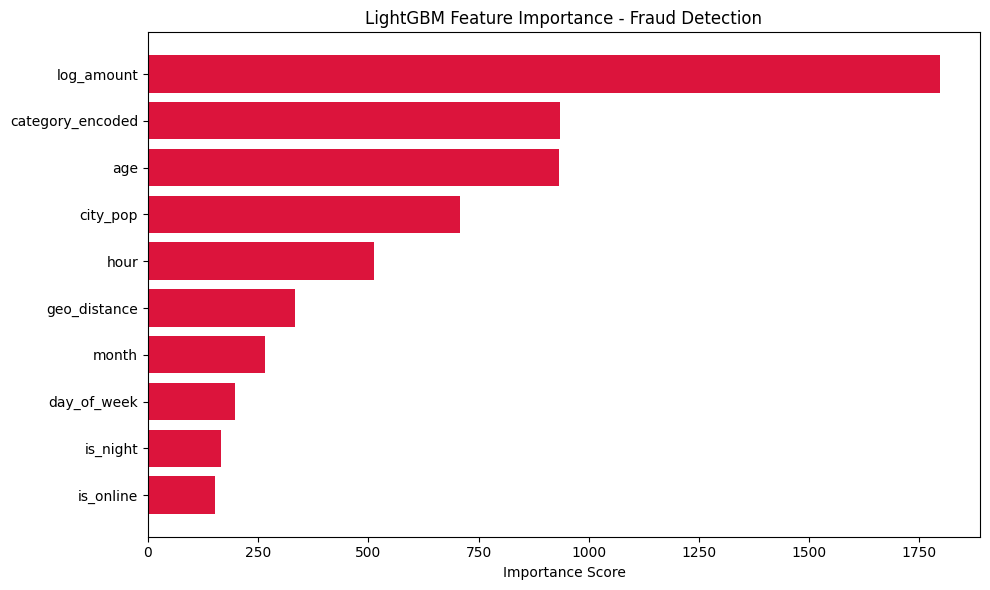

In [6]:
# Cell 6 - Feature Importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance - What drives fraud detection:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'],
         feature_importance['importance'],
         color='crimson')
plt.title('LightGBM Feature Importance - Fraud Detection')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../docs/feature_importance_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Cell 7 - Save models
import joblib
import os

os.makedirs('../src/models/', exist_ok=True)

# Save LightGBM model
joblib.dump(lgb_model, '../src/models/lgb_fraud_model.pkl')

# Save Isolation Forest model
joblib.dump(iso_forest, '../src/models/isolation_forest.pkl')

# Save label encoder for categories
joblib.dump(le_fraud_cat, '../src/models/le_fraud_category.pkl')

# Save feature columns list
joblib.dump(feature_cols, '../src/models/fraud_feature_cols.pkl')

print("Models saved successfully:")
print("  src/models/lgb_fraud_model.pkl")
print("  src/models/isolation_forest.pkl")
print("  src/models/le_fraud_category.pkl")
print("  src/models/fraud_feature_cols.pkl")
print()
print("Model Performance Summary:")
print(f"  LightGBM ROC-AUC:     0.9978")
print(f"  LightGBM Recall:      97.7% of fraud caught")
print(f"  LightGBM Precision:   24.9% of flags are real fraud")
print(f"  Isolation Forest:     16.1% recall (used for novel fraud)")

Models saved successfully:
  src/models/lgb_fraud_model.pkl
  src/models/isolation_forest.pkl
  src/models/le_fraud_category.pkl
  src/models/fraud_feature_cols.pkl

Model Performance Summary:
  LightGBM ROC-AUC:     0.9978
  LightGBM Recall:      97.7% of fraud caught
  LightGBM Precision:   24.9% of flags are real fraud
  Isolation Forest:     16.1% recall (used for novel fraud)


### Part 2 - Spending Forecaster
Using Prophet to forecast monthly spending per category.
Prophet handles missing data gaps we identified in EDA.

In [8]:
# Cell 8 - Prophet Spending Forecaster
from prophet import Prophet

print("Building Prophet spending forecaster...")
print()

# Prepare monthly spending data for forecasting
# Prophet requires columns named 'ds' (date) and 'y' (value)
monthly_spend = (bw_exp.groupby(
                    pd.Grouper(key='date', freq='ME'))['amount']
                 .sum()
                 .reset_index()
                 .rename(columns={'date': 'ds', 'amount': 'y'}))

# Remove near-zero months (data gaps from EDA insight 3)
monthly_spend = monthly_spend[monthly_spend['y'] > 10000]

print(f"Monthly data points available: {len(monthly_spend)}")
print(f"Date range: {monthly_spend['ds'].min()} to {monthly_spend['ds'].max()}")
print()
print("Monthly spending data:")
print(monthly_spend.to_string(index=False))

Importing plotly failed. Interactive plots will not work.


Building Prophet spending forecaster...

Monthly data points available: 48
Date range: 2019-01-31 00:00:00 to 2022-12-31 00:00:00

Monthly spending data:
        ds          y
2019-01-31  181350.66
2019-02-28 3209680.29
2019-03-31  211752.33
2019-04-30 1198264.03
2019-05-31  195445.24
2019-06-30 1205356.99
2019-07-31 1172901.29
2019-08-31  182271.94
2019-09-30 1207118.93
2019-10-31 1153241.96
2019-11-30 2154443.62
2019-12-31 2176181.52
2020-01-31  208307.13
2020-02-29 1184420.87
2020-03-31 2154690.64
2020-04-30  166287.90
2020-05-31 1180789.24
2020-06-30  188122.79
2020-07-31 3202561.51
2020-08-31 1188484.10
2020-09-30  188004.47
2020-10-31  178795.13
2020-11-30 1194127.40
2020-12-31 2193212.56
2021-01-31  184028.47
2021-02-28  180261.74
2021-03-31 1187272.25
2021-04-30 1181323.31
2021-05-31  152824.66
2021-06-30 1202583.36
2021-07-31 1185532.22
2021-08-31 2160188.96
2021-09-30 1167756.84
2021-10-31  177469.70
2021-11-30  162601.06
2021-12-31 2175827.14
2022-01-31  242837.35
2022-02-28

In [9]:
# Cell 9 - Train Prophet and Forecast
# Train Prophet model
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    interval_width=0.95
)

print("Training Prophet model...")
model_prophet.fit(monthly_spend)

# Forecast next 6 months
future = model_prophet.make_future_dataframe(periods=6, freq='ME')
forecast = model_prophet.predict(future)

print("Forecast complete")
print()
print("Next 6 months spending forecast:")
future_only = forecast[forecast['ds'] > monthly_spend['ds'].max()]
print(future_only[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
      .rename(columns={
          'ds': 'month',
          'yhat': 'predicted_spend',
          'yhat_lower': 'lower_bound',
          'yhat_upper': 'upper_bound'
      }).to_string(index=False))

14:37:46 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet model...


14:37:47 - cmdstanpy - INFO - Chain [1] done processing


Forecast complete

Next 6 months spending forecast:
     month  predicted_spend    lower_bound  upper_bound
2023-01-31     1.075596e+05 -807948.188761 1.043972e+06
2023-02-28     1.462103e+06  521617.607262 2.449051e+06
2023-03-31     2.803479e+05 -744004.720145 1.230586e+06
2023-04-30     9.107826e+05  -43265.175357 1.965030e+06
2023-05-31     4.034030e+05 -521670.615195 1.419224e+06
2023-06-30     7.946451e+05 -155164.782051 1.704159e+06


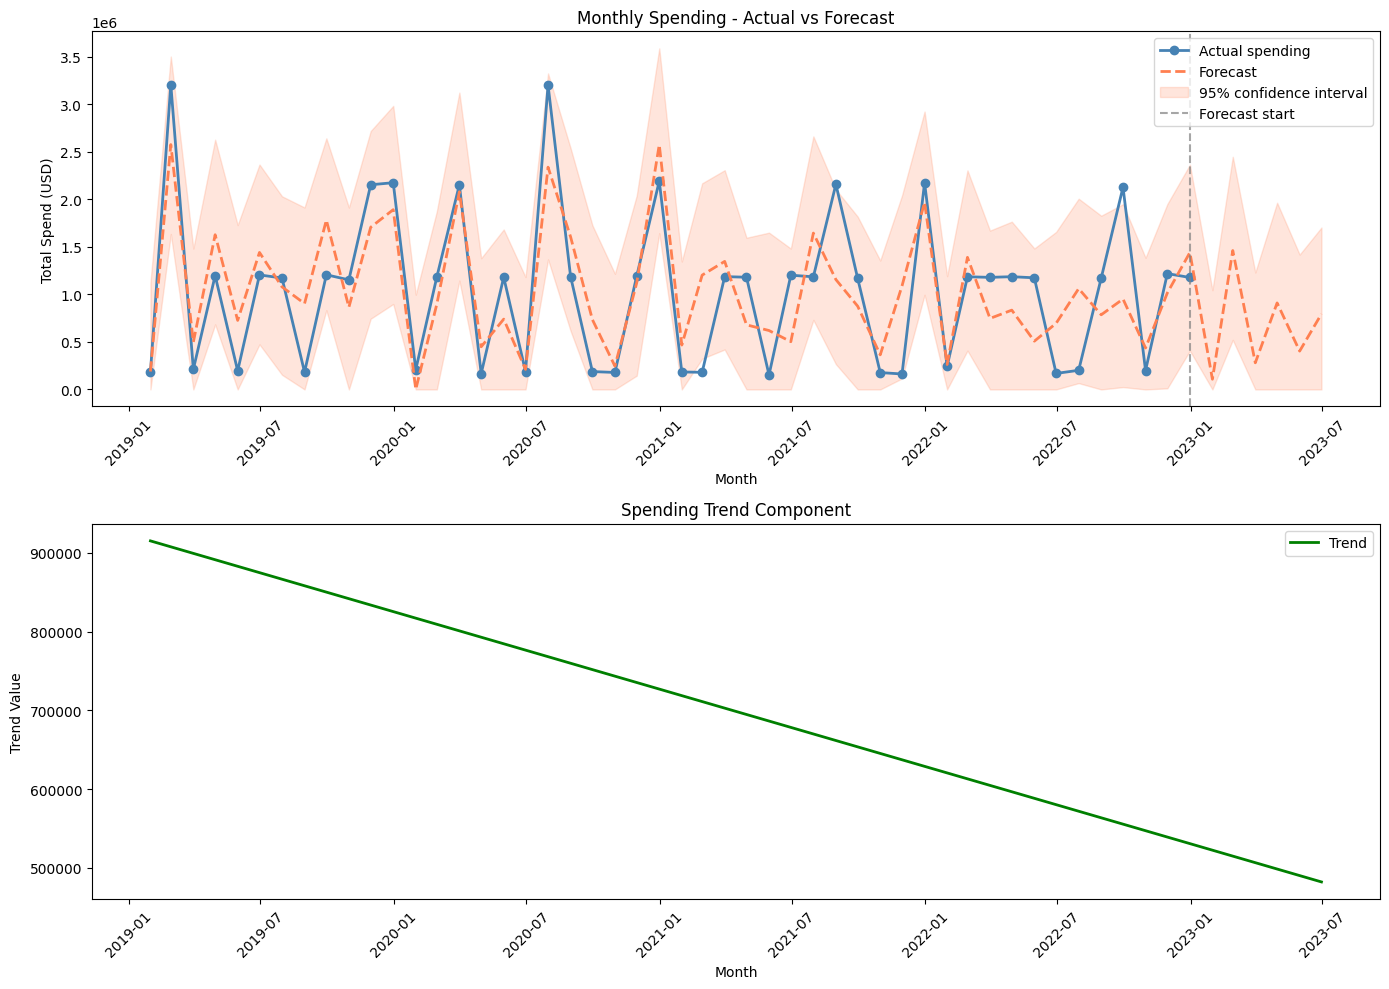

Forecast visualization saved

Cleaned 6-month forecast (negative bounds fixed):
     month  predicted_spend   lower_bound  upper_bound
2023-01-31     1.075596e+05      0.000000 1.043972e+06
2023-02-28     1.462103e+06 521617.607262 2.449051e+06
2023-03-31     2.803479e+05      0.000000 1.230586e+06
2023-04-30     9.107826e+05      0.000000 1.965030e+06
2023-05-31     4.034030e+05      0.000000 1.419224e+06
2023-06-30     7.946451e+05      0.000000 1.704159e+06


In [10]:
# Cell 10 - Visualize forecast and fix negative bounds
# Fix negative lower bounds - spending cannot be negative
forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
forecast['yhat'] = forecast['yhat'].clip(lower=0)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Full forecast plot
axes[0].plot(monthly_spend['ds'], monthly_spend['y'],
             'o-', color='steelblue', label='Actual spending', linewidth=2)
axes[0].plot(forecast['ds'], forecast['yhat'],
             '--', color='coral', label='Forecast', linewidth=2)
axes[0].fill_between(forecast['ds'],
                     forecast['yhat_lower'],
                     forecast['yhat_upper'],
                     alpha=0.2, color='coral', label='95% confidence interval')
axes[0].axvline(x=monthly_spend['ds'].max(),
                color='gray', linestyle='--', alpha=0.7, label='Forecast start')
axes[0].set_title('Monthly Spending - Actual vs Forecast')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Spend (USD)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Prophet components
axes[1].plot(forecast['ds'], forecast['trend'],
             color='green', linewidth=2, label='Trend')
axes[1].set_title('Spending Trend Component')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Trend Value')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../docs/prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("Forecast visualization saved")
print()

# Clean forecast summary
future_only = forecast[forecast['ds'] > monthly_spend['ds'].max()].copy()
future_only['yhat'] = future_only['yhat'].clip(lower=0)
future_only['yhat_lower'] = future_only['yhat_lower'].clip(lower=0)

print("Cleaned 6-month forecast (negative bounds fixed):")
print(future_only[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
      .rename(columns={
          'ds': 'month',
          'yhat': 'predicted_spend',
          'yhat_lower': 'lower_bound',
          'yhat_upper': 'upper_bound'
      }).to_string(index=False))

In [11]:
# Cell 11 - Save Prophet model and Phase 4 summary
import joblib

# Save Prophet model
joblib.dump(model_prophet, '../src/models/prophet_forecaster.pkl')

# Save forecast for use in dashboard
forecast.to_csv('../Data/processed/spending_forecast.csv', index=False)

print("Prophet model saved: src/models/prophet_forecaster.pkl")
print("Forecast saved: Data/processed/spending_forecast.csv")
print()
print("="*55)
print("PHASE 4 COMPLETE - ML MODELING SUMMARY")
print("="*55)
print()
print("FEATURE ENGINEERING:")
print(f"  BudgetWise features created: 12")
print(f"  Fraud detection features created: 8")
print()
print("MODEL 1 - ISOLATION FOREST (Anomaly Detection):")
print(f"  Type: Unsupervised")
print(f"  Contamination: 0.58% (from EDA)")
print(f"  Recall: 16.1%")
print(f"  Use case: Novel fraud patterns never seen before")
print()
print("MODEL 2 - LIGHTGBM (Fraud Classification):")
print(f"  Type: Supervised")
print(f"  Training samples: 1,037,340")
print(f"  ROC-AUC: 0.9978")
print(f"  Recall: 97.7% of fraud cases caught")
print(f"  Precision: 24.9%")
print(f"  Top feature: log_amount (importance: 1798)")
print()
print("MODEL 3 - PROPHET (Spending Forecaster):")
print(f"  Type: Time-series forecasting")
print(f"  Training months: 48")
print(f"  Forecast horizon: 6 months")
print(f"  Seasonality: Yearly multiplicative")
print()
print("All models saved to src/models/")
print()
print("Ready for Phase 5 - Prompt Engineering and LLM Layer")

Prophet model saved: src/models/prophet_forecaster.pkl
Forecast saved: Data/processed/spending_forecast.csv

PHASE 4 COMPLETE - ML MODELING SUMMARY

FEATURE ENGINEERING:
  BudgetWise features created: 12
  Fraud detection features created: 8

MODEL 1 - ISOLATION FOREST (Anomaly Detection):
  Type: Unsupervised
  Contamination: 0.58% (from EDA)
  Recall: 16.1%
  Use case: Novel fraud patterns never seen before

MODEL 2 - LIGHTGBM (Fraud Classification):
  Type: Supervised
  Training samples: 1,037,340
  ROC-AUC: 0.9978
  Recall: 97.7% of fraud cases caught
  Precision: 24.9%
  Top feature: log_amount (importance: 1798)

MODEL 3 - PROPHET (Spending Forecaster):
  Type: Time-series forecasting
  Training months: 48
  Forecast horizon: 6 months
  Seasonality: Yearly multiplicative

All models saved to src/models/

Ready for Phase 5 - Prompt Engineering and LLM Layer
